# Project 2 — Radiomics Feature Analysis

This notebook performs:
1. Correlation matrix of radiomics features
2. Spearman correlation with Agatston score
3. Kruskal-Wallis test across Agatston categories
4. Significant associations (p < 0.05)
5. t-SNE and UMAP visualizations
6. Unsupervised clustering (KMeans)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

ROOT = Path(r'C:\Users\level\OneDrive\Escritorio\COCA')
CSV  = ROOT / 'project2_radiomics' / 'radiomics_features.csv'
OUT  = ROOT / 'project2_radiomics'

df = pd.read_csv(CSV)
print(f'Loaded {len(df)} scans, {len(df.columns)} columns')
df.head()

Loaded 30 scans, 20 columns


,scan_id,patient_id,calcium_voxels,agatston_score,agatston_category,hu_max,hu_mean,calcium_volume_mm3,shape_Sphericity,shape_SurfaceVolumeRatio,shape_Maximum3DDiameter,glcm_Contrast,glcm_Correlation,glcm_Id,glszm_SmallAreaEmphasis,glszm_LargeAreaEmphasis,glszm_ZonePercentage,glrlm_ShortRunEmphasis,glrlm_LongRunEmphasis,glrlm_RunPercentage
0,b00c41a95701,358,247,53.90,1-99,385.0,209.86,63.21,0.475250,2.451902,22.163258,8.658512,-0.172593,0.438533,0.808992,2.543478,0.730159,0.979891,1.080436,0.974359
1,8ea26fca1902,441,644,268.03,100-399,556.0,224.53,276.36,0.384657,1.775549,107.175555,24.665742,0.322153,0.344696,0.762112,3.812500,0.644689,0.972763,1.116511,0.964497
2,220a72484bed,206,184,98.00,1-99,511.0,277.22,73.50,0.709870,1.565655,10.131140,37.860261,0.150574,0.252358,0.855694,1.980000,0.793651,0.986378,1.060384,0.981685
3,b000fe01f9c4,46,1561,449.82,>=400,652.0,248.64,408.66,0.376594,1.713902,97.359385,31.644090,0.248090,0.306228,0.735823,3.157658,0.658754,0.975074,1.109685,0.967359
4,85d832423677,163,18,0.98,1-99,177.0,156.50,2.94,0.757892,3.639265,3.594440,5.250000,-0.520821,0.422222,0.850000,1.600000,0.833333,0.962500,1.150000,0.958333


In [2]:
# Define feature groups
SHAPE_FEATS = ['shape_Sphericity', 'shape_SurfaceVolumeRatio', 'shape_Maximum3DDiameter']
GLCM_FEATS  = ['glcm_Contrast', 'glcm_Correlation', 'glcm_InverseDifferenceMoment']
GLSZM_FEATS = ['glszm_SmallAreaEmphasis', 'glszm_LargeAreaEmphasis', 'glszm_ZonePercentage']
GLRLM_FEATS = ['glrlm_ShortRunEmphasis', 'glrlm_LongRunEmphasis', 'glrlm_RunPercentage']
OPTIONAL    = ['hu_max', 'hu_mean', 'calcium_volume_mm3']

ALL_FEATS = SHAPE_FEATS + GLCM_FEATS + GLSZM_FEATS + GLRLM_FEATS + OPTIONAL
ALL_FEATS = [f for f in ALL_FEATS if f in df.columns]

print(f'Feature columns available: {ALL_FEATS}')

# Impute missing values with column median
imputer = SimpleImputer(strategy='median')
feat_matrix = pd.DataFrame(
    imputer.fit_transform(df[ALL_FEATS]),
    columns=ALL_FEATS
)
print('Missing values after imputation:', feat_matrix.isnull().sum().sum())

Feature columns available: ['shape_Sphericity', 'shape_SurfaceVolumeRatio', 'shape_Maximum3DDiameter', 'glcm_Contrast', 'glcm_Correlation', 'glszm_SmallAreaEmphasis', 'glszm_LargeAreaEmphasis', 'glszm_ZonePercentage', 'glrlm_ShortRunEmphasis', 'glrlm_LongRunEmphasis', 'glrlm_RunPercentage', 'hu_max', 'hu_mean', 'calcium_volume_mm3']
Missing values after imputation: 0


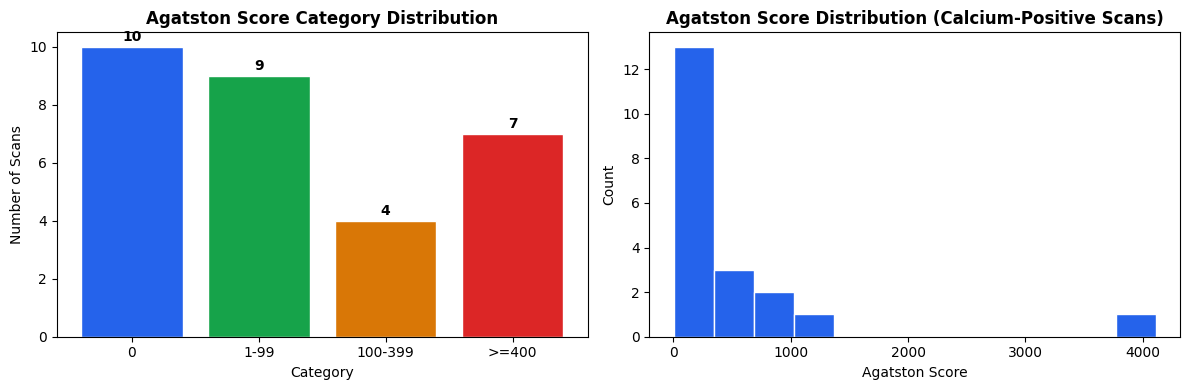

Agatston stats:
count      30.00
mean      330.64
std       786.55
min         0.00
25%         0.00
50%        52.43
75%       287.51
max      4112.57
Name: agatston_score, dtype: float64


In [3]:
#  Agatston distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cat_counts = df['agatston_category'].value_counts().reindex(['0', '1-99', '100-399', '>=400'], fill_value=0)
axes[0].bar(cat_counts.index, cat_counts.values, color=['#2563eb','#16a34a','#d97706','#dc2626'], edgecolor='white')
axes[0].set_title('Agatston Score Category Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Scans')
for i, v in enumerate(cat_counts.values):
    axes[0].text(i, v + 0.2, str(v), ha='center', fontweight='bold')

pos_scores = df[df['agatston_score'] > 0]['agatston_score']
axes[1].hist(pos_scores, bins=12, color='#2563eb', edgecolor='white')
axes[1].set_title('Agatston Score Distribution (Calcium-Positive Scans)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Agatston Score')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(OUT / 'agatston_distribution.png', dpi=150)
plt.show()
print('Agatston stats:')
print(df['agatston_score'].describe().round(2))

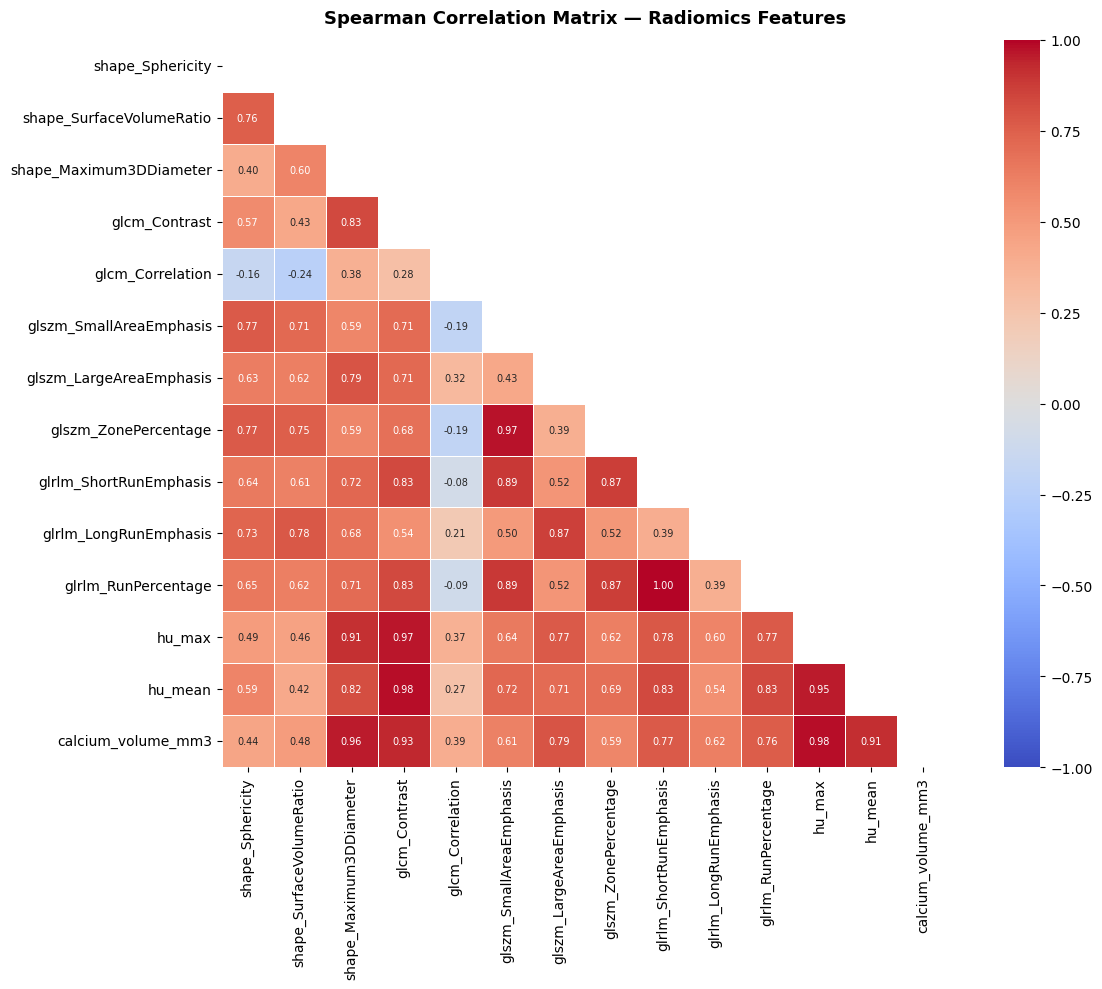

In [4]:
#Correlation matrix
corr = feat_matrix.corr(method='spearman')

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 7}, vmin=-1, vmax=1)
ax.set_title('Spearman Correlation Matrix — Radiomics Features', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(OUT / 'correlation_matrix.png', dpi=150)
plt.show()

In [5]:
# Spearman correlation with Agatston score
spearman_results = []
for feat in ALL_FEATS:
    rho, pval = stats.spearmanr(feat_matrix[feat], df['agatston_score'], nan_policy='omit')
    spearman_results.append({'feature': feat, 'spearman_rho': round(rho, 4), 'p_value': round(pval, 4)})

spearman_df = pd.DataFrame(spearman_results).sort_values('spearman_rho', key=abs, ascending=False)
spearman_df.to_csv(OUT / 'spearman_results.csv', index=False)

print('=== Spearman Correlation with Agatston Score ===')
print(spearman_df.to_string(index=False))

sig = spearman_df[spearman_df['p_value'] < 0.05]
print(f'\nSignificant associations (p<0.05): {len(sig)}')
print(sig.to_string(index=False))

=== Spearman Correlation with Agatston Score ===
                 feature  spearman_rho  p_value
      calcium_volume_mm3        0.9955   0.0000
                  hu_max        0.9805   0.0000
 shape_Maximum3DDiameter        0.9516   0.0000
           glcm_Contrast        0.9378   0.0000
                 hu_mean        0.9260   0.0000
 glszm_LargeAreaEmphasis        0.7911   0.0000
  glrlm_ShortRunEmphasis        0.7703   0.0000
     glrlm_RunPercentage        0.7583   0.0000
   glrlm_LongRunEmphasis        0.6220   0.0002
 glszm_SmallAreaEmphasis        0.6179   0.0003
    glszm_ZonePercentage        0.5959   0.0005
shape_SurfaceVolumeRatio        0.4696   0.0088
        shape_Sphericity        0.4527   0.0120
        glcm_Correlation        0.4137   0.0231

Significant associations (p<0.05): 14
                 feature  spearman_rho  p_value
      calcium_volume_mm3        0.9955   0.0000
                  hu_max        0.9805   0.0000
 shape_Maximum3DDiameter        0.9516   0.0000


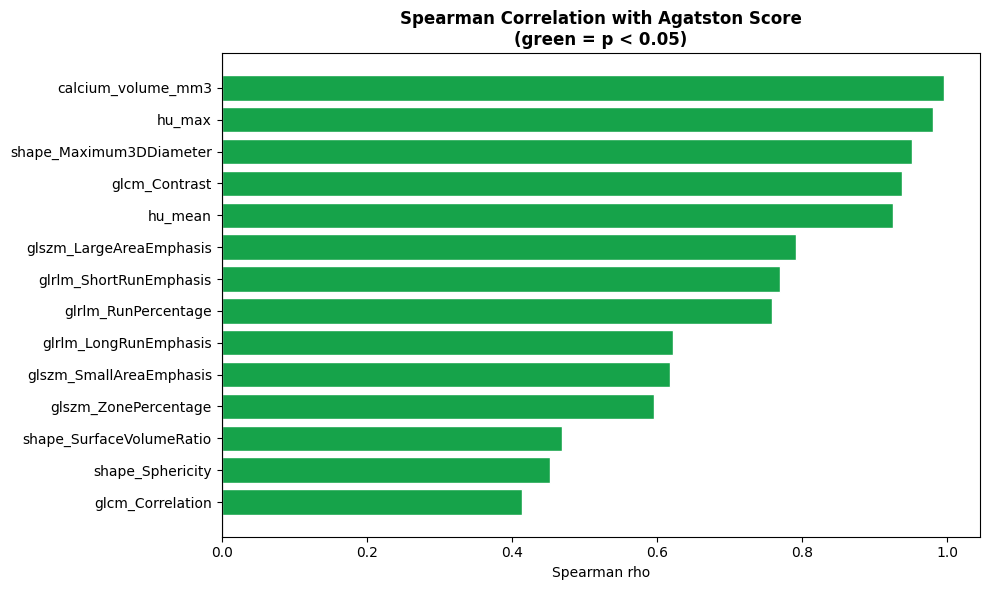

In [6]:
# Spearman bar plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#16a34a' if p < 0.05 else '#94a3b8' for p in spearman_df['p_value']]
bars = ax.barh(spearman_df['feature'], spearman_df['spearman_rho'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Spearman rho')
ax.set_title('Spearman Correlation with Agatston Score\n(green = p < 0.05)', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUT / 'spearman_barplot.png', dpi=150)
plt.show()

In [15]:
# Kruskal-Wallis across Agatston categories
cats = ['0', '1-99', '100-399', '>=400']
kruskal_results = []

for feat in ALL_FEATS:
    groups = [feat_matrix.loc[df['agatston_category'] == c, feat].dropna().values for c in cats]
    groups = [g for g in groups if len(g) >= 2]  # need at least 2 samples
    if len(groups) < 2:
        continue
    stat, pval = stats.kruskal(*groups)
    kruskal_results.append({'feature': feat, 'kruskal_stat': round(stat, 4), 'p_value': round(pval, 4)})

kruskal_df = pd.DataFrame(kruskal_results).sort_values('p_value')
kruskal_df.to_csv(OUT / 'kruskal_results.csv', index=False)

print('=== Kruskal-Wallis Test (across Agatston categories) ===')
print(kruskal_df.to_string(index=False))

sig_k = kruskal_df[kruskal_df['p_value'] < 0.05]
print(f'\nSignificant (p<0.05): {len(sig_k)}')
print(sig_k.to_string(index=False))

=== Kruskal-Wallis Test (across Agatston categories) ===
                 feature  kruskal_stat  p_value
        shape_Sphericity       24.3807   0.0000
shape_SurfaceVolumeRatio       24.9813   0.0000
 shape_Maximum3DDiameter       24.7380   0.0000
           glcm_Contrast       26.0239   0.0000
                 hu_mean       25.7574   0.0000
      calcium_volume_mm3       27.5977   0.0000
                  hu_max       26.9463   0.0000
 glszm_SmallAreaEmphasis       21.3583   0.0001
     glrlm_RunPercentage       20.6358   0.0001
    glszm_ZonePercentage       20.9958   0.0001
 glszm_LargeAreaEmphasis       20.9147   0.0001
  glrlm_ShortRunEmphasis       20.7523   0.0001
   glrlm_LongRunEmphasis       20.7789   0.0001
        glcm_Correlation        7.3993   0.0602

Significant (p<0.05): 13
                 feature  kruskal_stat  p_value
        shape_Sphericity       24.3807   0.0000
shape_SurfaceVolumeRatio       24.9813   0.0000
 shape_Maximum3DDiameter       24.7380   0.0000
     

C:\Users\level\AppData\Local\Temp\ipykernel_28536\2412524816.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='agatston_category', y=feat, order=order,
C:\Users\level\AppData\Local\Temp\ipykernel_28536\2412524816.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='agatston_category', y=feat, order=order,
C:\Users\level\AppData\Local\Temp\ipykernel_28536\2412524816.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='agatston_category', y=feat, order=order,
C:\Users\level\AppData\Local\Te

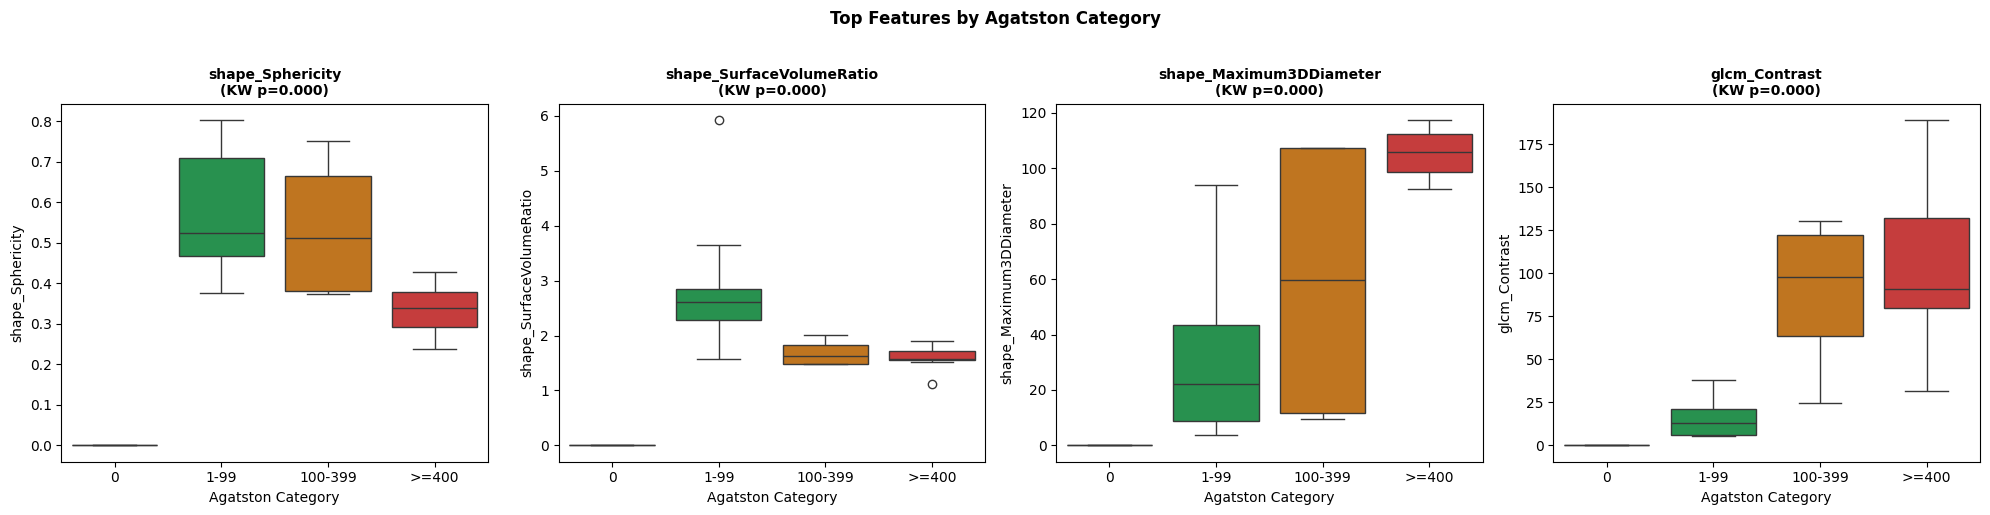

In [16]:
# ── Boxplot: top significant features across Agatston categories ────────────
top_feats = kruskal_df.head(4)['feature'].tolist() if len(kruskal_df) >= 4 else kruskal_df['feature'].tolist()

if top_feats:
    fig, axes = plt.subplots(1, len(top_feats), figsize=(5*len(top_feats), 5))
    if len(top_feats) == 1: axes = [axes]
    palette = {'0': '#2563eb', '1-99': '#16a34a', '100-399': '#d97706', '>=400': '#dc2626'}

    plot_df = feat_matrix.copy()
    plot_df['agatston_category'] = df['agatston_category'].values

    for ax, feat in zip(axes, top_feats):
        order = [c for c in cats if c in plot_df['agatston_category'].values]
        sns.boxplot(data=plot_df, x='agatston_category', y=feat, order=order,
                    palette=palette, ax=ax)
        pval = kruskal_df.set_index('feature').loc[feat, 'p_value']
        ax.set_title(f'{feat}\n(KW p={pval:.3f})', fontsize=10, fontweight='bold')
        ax.set_xlabel('Agatston Category')

    plt.suptitle('Top Features by Agatston Category', fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(OUT / 'boxplots_top_features.png', dpi=150, bbox_inches='tight')
    plt.show()

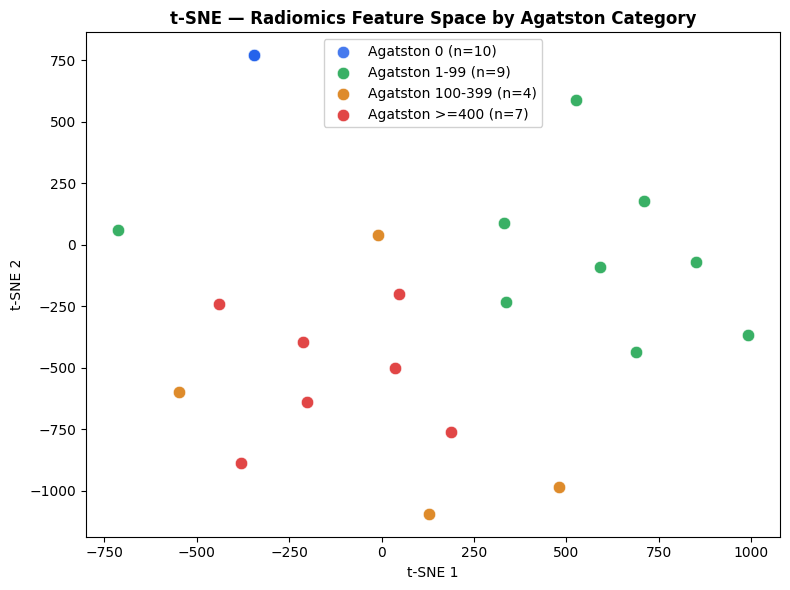

t-SNE plot saved.


In [20]:
# t-SNE visualization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(feat_matrix)

perplexity = min(10, len(df) - 1)
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

cat_colors = {'0': '#2563eb', '1-99': '#16a34a', '100-399': '#d97706', '>=400': '#dc2626'}

fig, ax = plt.subplots(figsize=(8, 6))
for cat in cats:
    mask = df['agatston_category'].values == cat
    if mask.sum() == 0: continue
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               label=f'Agatston {cat} (n={mask.sum()})',
               color=cat_colors[cat], s=80, alpha=0.85, edgecolors='white', linewidths=0.5)

ax.set_title('t-SNE — Radiomics Feature Space by Agatston Category', fontweight='bold')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig(OUT / 'tsne_agatston.png', dpi=150)
plt.show()
print('t-SNE plot saved.')

In [23]:
# UMAP visualization
try:
    import umap
    reducer = umap.UMAP(n_neighbors=min(10, len(df)-1), random_state=12)
    X_umap = reducer.fit_transform(X_scaled)

    fig, ax = plt.subplots(figsize=(8, 6))
    for cat in cats:
        mask = df['agatston_category'].values == cat
        if mask.sum() == 0: continue
        ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
                   label=f'Agatston {cat} (n={mask.sum()})',
                   color=cat_colors[cat], s=80, alpha=0.85, edgecolors='white', linewidths=0.5)

    ax.set_title('UMAP — Radiomics Feature Space by Agatston Category', fontweight='bold')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.legend(framealpha=0.9)
    plt.tight_layout()
    plt.savefig(OUT / 'umap_agatston.png', dpi=150)
    plt.show()
    print('UMAP plot saved.')
except ImportError:
    print('umap-learn not installed, skipping UMAP. Run: pip install umap-learn')

umap-learn not installed, skipping UMAP. Run: pip install umap-learn


=== Cluster vs Agatston Category ===
agatston_category   0  1-99  100-399  >=400
cluster                                    
0                   0     7        4      1
1                  10     0        0      0
2                   0     0        0      6
3                   0     2        0      0

Cluster profiles saved to cluster_profiles.csv


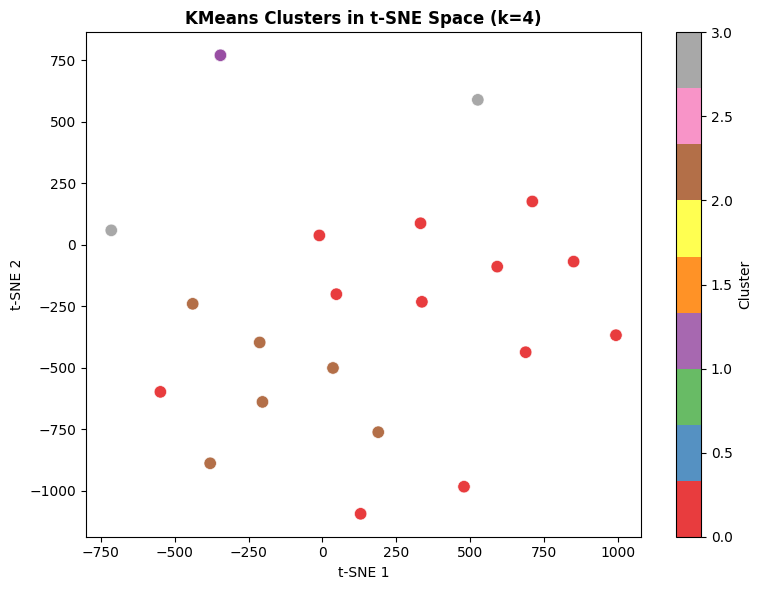

In [24]:
# Unsupervised clustering (KMeans, k=4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Cross-tabulate clusters vs Agatston categories
df['cluster'] = clusters
cross = pd.crosstab(df['cluster'], df['agatston_category'])
print('=== Cluster vs Agatston Category ===')
print(cross)

# Cluster profile: mean feature values per cluster
cluster_profile = feat_matrix.copy()
cluster_profile['cluster'] = clusters
profile = cluster_profile.groupby('cluster').mean().round(4)
profile.to_csv(OUT / 'cluster_profiles.csv')
print('\nCluster profiles saved to cluster_profiles.csv')

# Plot clusters in t-SNE space
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters,
                     cmap='Set1', s=80, alpha=0.85, edgecolors='white', linewidths=0.5)
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.set_title('KMeans Clusters in t-SNE Space (k=4)', fontweight='bold')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.savefig(OUT / 'tsne_clusters.png', dpi=150)
plt.show()

In [25]:
# Summary of significant associations
print('=' * 55)
print('SUMMARY OF SIGNIFICANT ASSOCIATIONS (p < 0.05)')
print('=' * 55)

print('\n-- Spearman (continuous Agatston score) --')
sig_s = spearman_df[spearman_df['p_value'] < 0.05]
if len(sig_s):
    print(sig_s.to_string(index=False))
else:
    print('None (small sample — expected with n=30)')

print('\n-- Kruskal-Wallis (across Agatston categories) --')
sig_k = kruskal_df[kruskal_df['p_value'] < 0.05]
if len(sig_k):
    print(sig_k.to_string(index=False))
else:
    print('None (small sample — expected with n=30)')

print('\nFiles saved:')
for f in sorted(OUT.glob('*.csv')) :
    print(f'  {f.name}')
for f in sorted(OUT.glob('*.png')):
    print(f'  {f.name}')

SUMMARY OF SIGNIFICANT ASSOCIATIONS (p < 0.05)

-- Spearman (continuous Agatston score) --
                 feature  spearman_rho  p_value
      calcium_volume_mm3        0.9955   0.0000
                  hu_max        0.9805   0.0000
 shape_Maximum3DDiameter        0.9516   0.0000
           glcm_Contrast        0.9378   0.0000
                 hu_mean        0.9260   0.0000
 glszm_LargeAreaEmphasis        0.7911   0.0000
  glrlm_ShortRunEmphasis        0.7703   0.0000
     glrlm_RunPercentage        0.7583   0.0000
   glrlm_LongRunEmphasis        0.6220   0.0002
 glszm_SmallAreaEmphasis        0.6179   0.0003
    glszm_ZonePercentage        0.5959   0.0005
shape_SurfaceVolumeRatio        0.4696   0.0088
        shape_Sphericity        0.4527   0.0120
        glcm_Correlation        0.4137   0.0231

-- Kruskal-Wallis (across Agatston categories) --
                 feature  kruskal_stat  p_value
        shape_Sphericity       24.3807   0.0000
shape_SurfaceVolumeRatio       24.9813   0